In [5]:
from google.colab import files

uploaded = files.upload()

Saving netflix_users.csv to netflix_users.csv


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

In [7]:
df = pd.read_csv("netflix_users.csv")

df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [ ]:
PART A — Dataset Understanding
Q1 First Five Records

In [8]:
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [ ]:
Q2 Rows and Columns

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 750
Columns: 10


In [ ]:
Q3 Column Names

In [10]:
print(df.columns)

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


In [ ]:
Q4 Numerical and Categorical Features

In [11]:
print("Numerical Features")

numerical = df.select_dtypes(include=['int64','float64'])
print(numerical.columns.tolist())

print("\nCategorical Features")

categorical = df.select_dtypes(include=['object'])
print(categorical.columns.tolist())

Numerical Features
['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']

Categorical Features
['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


In [ ]:
Q5 Missing Values

In [12]:
df.isnull().sum()

,0
UserID,0
Age,0
Gender,0
SubscriptionType,0
WatchHoursPerWeek,0
DevicesUsed,0
FavoriteGenre,0
AdClicks,0
MonthlySpend,0
SubscriptionRenewed,0


In [ ]:
PART B — Exploratory Data Analysis
Q6 Average Age

In [13]:
print("Average Age =", df['Age'].mean())

Average Age = 41.824


In [ ]:
Q7 Average Watch Hours

In [14]:
print("Average Watch Hours =", df['WatchHoursPerWeek'].mean())

Average Watch Hours = 14.236


In [ ]:
Q8 Average Monthly Spending

In [15]:
print("Average Monthly Spending =", df['MonthlySpend'].mean())

Average Monthly Spending = 689.9053333333334


In [ ]:
Q9 Subscription Counts

In [16]:
df['SubscriptionType'].value_counts()

,count
SubscriptionType,
Basic,342
Premium,279
VIP,129


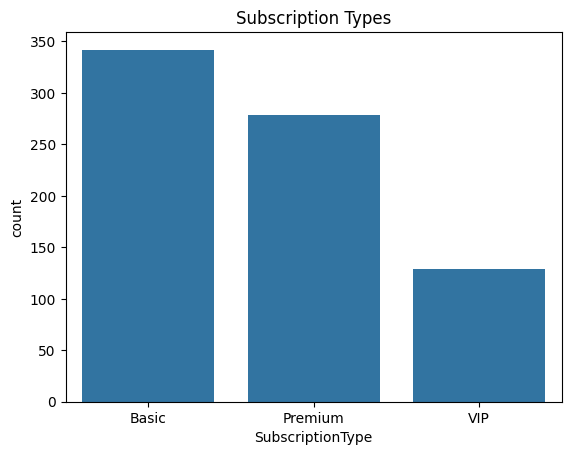

In [17]:
sns.countplot(x='SubscriptionType', data=df)

plt.title("Subscription Types")
plt.show()

In [ ]:
Q10 Renewal Percentage

In [18]:
renewed = (df['SubscriptionRenewed']=="Yes").sum()

total = len(df)

percentage = (renewed/total)*100

print("Renewal Percentage =", round(percentage,2), "%")

Renewal Percentage = 46.27 %


In [ ]:
PART C — Data Preparation
Q11 Encode Categorical Data

In [19]:
df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.columns:

    if df_encoded[column].dtype == 'object':

        df_encoded[column] = encoder.fit_transform(
            df_encoded[column]
        )

df_encoded.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


In [ ]:
Q12 Features and Target

In [20]:
y = df_encoded['SubscriptionRenewed']

In [21]:
X = df_encoded.drop(
    'SubscriptionRenewed',
    axis=1
)

In [ ]:
Q13 Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(600, 9)
(150, 9)


In [ ]:
PART D — Decision Tree
Q14 Train Model

In [23]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [ ]:
Q15 Accuracy

In [24]:
dt_predictions = dt.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("Decision Tree Accuracy =", dt_accuracy)

Decision Tree Accuracy = 0.5666666666666667


In [ ]:
Q16 Confusion Matrix

In [25]:
cm = confusion_matrix(
    y_test,
    dt_predictions
)

print(cm)

[[50 32]
 [33 35]]


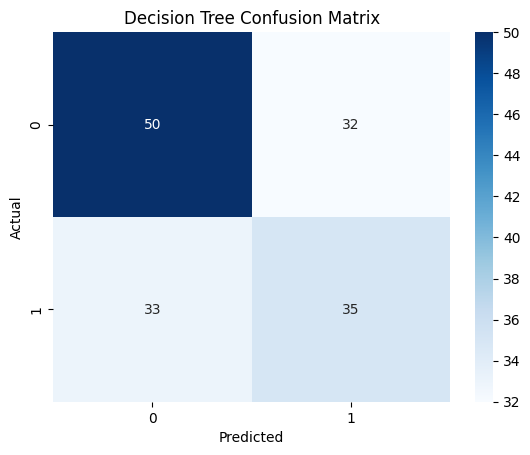

In [26]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
print(
    classification_report(
        y_test,
        dt_predictions
    )
)

              precision    recall  f1-score   support

           0       0.60      0.61      0.61        82
           1       0.52      0.51      0.52        68

    accuracy                           0.57       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.57      0.57      0.57       150



In [ ]:
PART E — KNN
Q17 Train KNN

In [28]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

KNeighborsClassifier()

In [29]:
#Accuracy
knn_predictions = knn.predict(
    X_test
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy =", knn_accuracy)

KNN Accuracy = 0.6


In [ ]:
Q18 Compare

In [30]:
print("Decision Tree =", dt_accuracy)

print("KNN =", knn_accuracy)

Decision Tree = 0.5666666666666667
KNN = 0.6


In [31]:
if dt_accuracy > knn_accuracy:
    print("Decision Tree performs better")

elif knn_accuracy > dt_accuracy:
    print("KNN performs better")

else:
    print("Both models perform equally")

KNN performs better


In [ ]:
PART F — Linear Regression
Q19 Predict Monthly Spending

In [32]:
y_reg = df_encoded['MonthlySpend']

In [33]:
X_reg = df_encoded.drop(
    'MonthlySpend',
    axis=1
)

In [ ]:
Split Data

In [34]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [ ]:
Train Model

In [35]:
lr = LinearRegression()

lr.fit(
    X_train_reg,
    y_train_reg
)

LinearRegression()

In [36]:
predictions = lr.predict(
    X_test_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        predictions
    )
)

r2 = r2_score(
    y_test_reg,
    predictions
)

print("RMSE =", rmse)

print("R2 =", r2)

RMSE = 70.13316152015105
R2 = 0.9660274555245927


In [ ]:
Q20 Predict New User Spending

In [37]:
new_user = pd.DataFrame({
    'UserID':[1001],
    'Age':[30],
    'Gender':[1],
    'SubscriptionType':[2],
    'WatchHoursPerWeek':[15],
    'DevicesUsed':[3],
    'FavoriteGenre':[0],
    'AdClicks':[5],
    'SubscriptionRenewed':[1]
})

In [38]:
predicted_spend = lr.predict(
    new_user
)

print(
    "Predicted Monthly Spending = ₹",
    round(predicted_spend[0],2)
)

Predicted Monthly Spending = ₹ 1322.86


In [39]:
print("PROJECT SUMMARY")

print("- Average Age:", round(df['Age'].mean(),2))

print("- Average Watch Hours:",
      round(df['WatchHoursPerWeek'].mean(),2))

print("- Average Monthly Spending:",
      round(df['MonthlySpend'].mean(),2))

print("- Decision Tree Accuracy:",
      round(dt_accuracy*100,2),"%")

print("- KNN Accuracy:",
      round(knn_accuracy*100,2),"%")

if dt_accuracy > knn_accuracy:
    print("- Best Model: Decision Tree")

else:
    print("- Best Model: KNN")

PROJECT SUMMARY
- Average Age: 41.82
- Average Watch Hours: 14.24
- Average Monthly Spending: 689.91
- Decision Tree Accuracy: 56.67 %
- KNN Accuracy: 60.0 %
- Best Model: KNN
